In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('insurance.csv')
df.head()
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [7]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1338, dtype: bool

In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

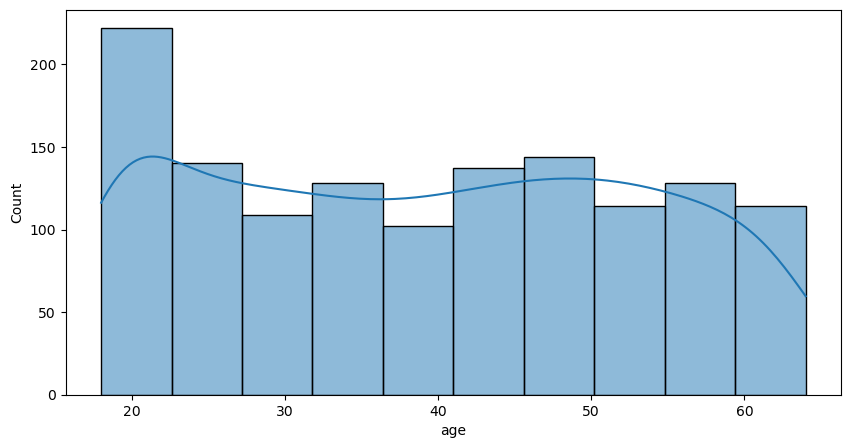

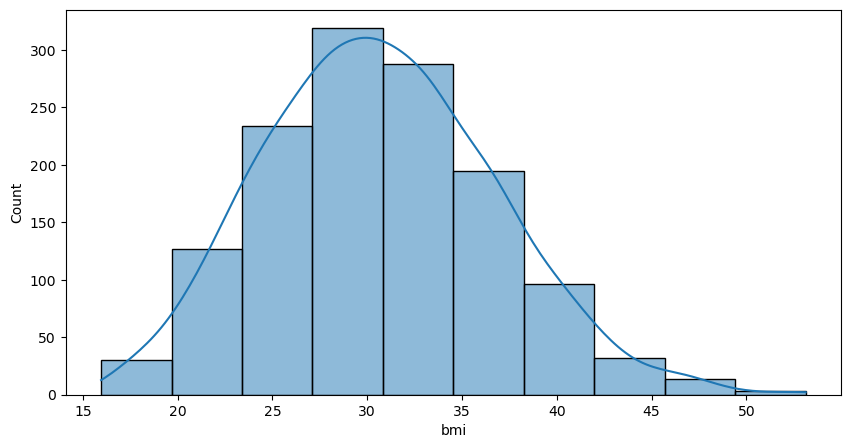

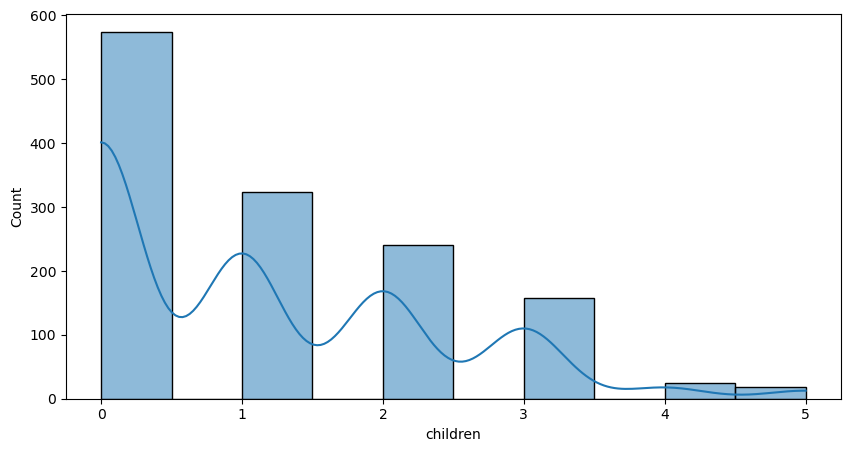

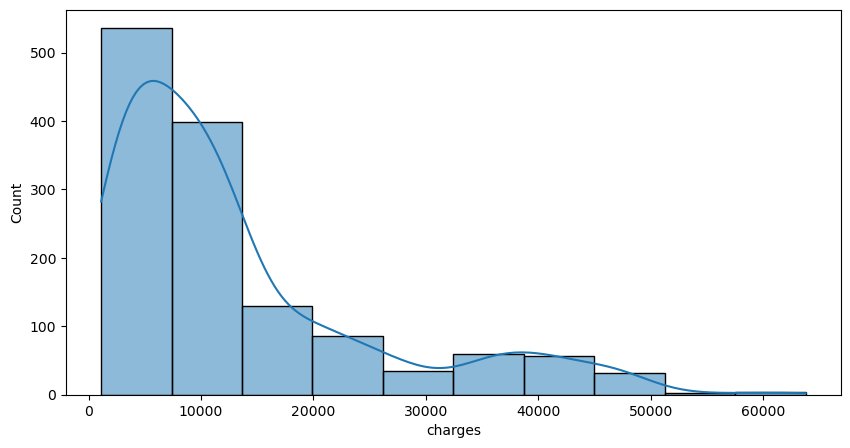

In [9]:
numeric_col = ['age'	, 'bmi' ,	'children' ,	'charges']
for col in numeric_col:
    plt.figure(figsize = (10 , 5))
    sns.histplot(df[col] , kde = True , bins = 10 )
    plt.show()

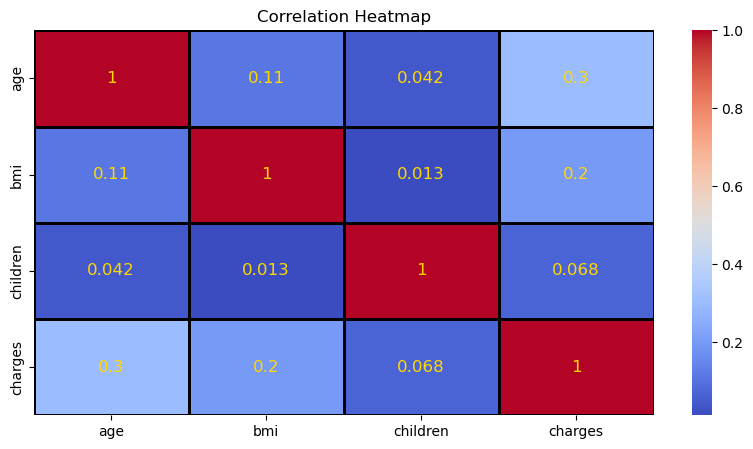

In [10]:
#heatmap
plt.figure(figsize=(10, 5))

v = sns.heatmap(
    df[numeric_col].corr(),
    annot=True,
    cmap='coolwarm',
    annot_kws={'fontsize': 12, 'color': 'gold'},
    linewidths=2,
    linecolor='black',
    xticklabels=True,
    yticklabels=True
)

v.set(title='Correlation Heatmap')

plt.show()

In [11]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [12]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

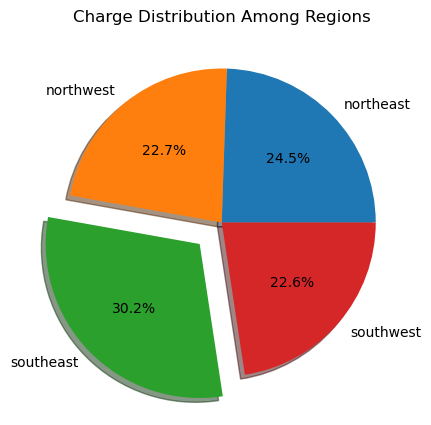

In [13]:
#pie chart
plt.figure(figsize=(10, 5))
region_data = df.groupby('region')['charges'].sum()
plt.pie(
    x = region_data,
    labels=region_data.index, 
    autopct='%.1f%%',   
    shadow=True, 
    explode=[0, 0, 0.2, 0]   
)
plt.title('Charge Distribution Among Regions')  
plt.show()

In [14]:
df['category_bmi'] = pd.cut(
    df['bmi'],
    bins= [0 , 18.5 , 25 ,30 , 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [15]:
df.head()

,age,sex,bmi,children,smoker,region,charges,category_bmi
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Overweight


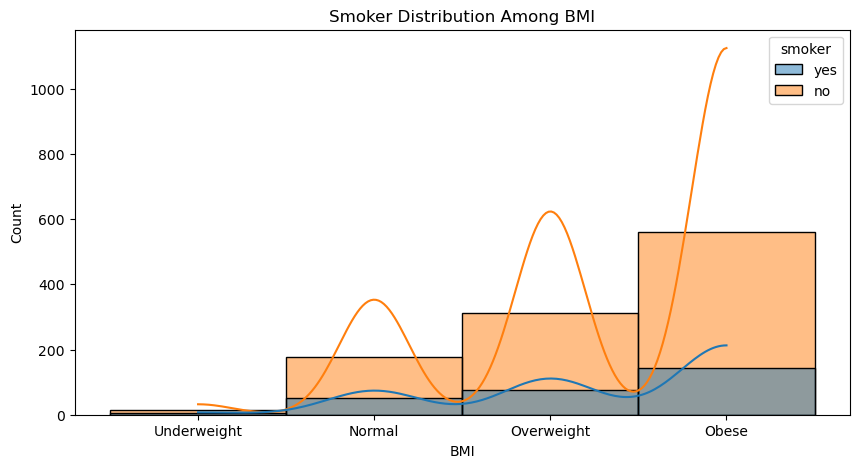

In [16]:
#barchart
plt.figure(figsize=(10, 5))

sns.histplot(
    x= df['category_bmi'],
    hue='smoker',
    kde = True,
    bins = 10,
    data=df
)

plt.title('Smoker Distribution Among BMI')
plt.xlabel('BMI')
plt.ylabel('Count')

plt.show()

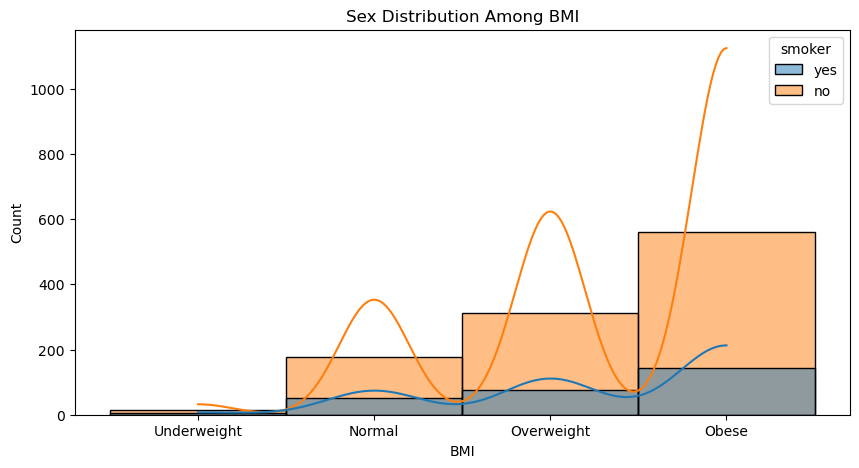

In [17]:
#barchart
plt.figure(figsize=(10, 5))

sns.histplot(
    x= df['category_bmi'],
    hue='smoker',
    kde = True,
    bins = 10,
    data=df
)

plt.title('Sex Distribution Among BMI')
plt.xlabel('BMI')
plt.ylabel('Count')

plt.show()

In [18]:
df.head()

,age,sex,bmi,children,smoker,region,charges,category_bmi
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Overweight


In [19]:
df['region'].isnull().sum()

np.int64(0)

In [20]:
df.dtypes

age                int64
sex               object
bmi              float64
children           int64
smoker            object
region            object
charges          float64
category_bmi    category
dtype: object

In [21]:
#label encodding 
# LB-> sex and smoker
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])

#on hot encoding
#OHE-> region , category_bmi
df = pd.get_dummies(df, columns=['region', 'category_bmi'])

In [22]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,category_bmi_Underweight,category_bmi_Normal,category_bmi_Overweight,category_bmi_Obese
0,19,0,27.900,0,1,16884.92400,False,False,False,True,False,False,True,False
1,18,1,33.770,1,0,1725.55230,False,False,True,False,False,False,False,True
2,28,1,33.000,3,0,4449.46200,False,False,True,False,False,False,False,True
3,33,1,22.705,0,0,21984.47061,False,True,False,False,False,True,False,False
4,32,1,28.880,0,0,3866.85520,False,True,False,False,False,False,True,False


In [23]:
## Training and Testing DAta
from sklearn.model_selection import train_test_split
x = df.drop(['charges'] , axis= 1)
y = df['charges']

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size= 0.2 , random_state= 42)

In [24]:
## scaling By standardScale
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)


In [25]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,category_bmi_Underweight,category_bmi_Normal,category_bmi_Overweight,category_bmi_Obese
0,19,0,27.900,0,1,16884.92400,False,False,False,True,False,False,True,False
1,18,1,33.770,1,0,1725.55230,False,False,True,False,False,False,False,True
2,28,1,33.000,3,0,4449.46200,False,False,True,False,False,False,False,True
3,33,1,22.705,0,0,21984.47061,False,True,False,False,False,True,False,False
4,32,1,28.880,0,0,3866.85520,False,True,False,False,False,False,True,False


In [26]:
df.dtypes

age                           int64
sex                           int64
bmi                         float64
children                      int64
smoker                        int64
charges                     float64
region_northeast               bool
region_northwest               bool
region_southeast               bool
region_southwest               bool
category_bmi_Underweight       bool
category_bmi_Normal            bool
category_bmi_Overweight        bool
category_bmi_Obese             bool
dtype: object

In [27]:
#Linear Regression
from sklearn.linear_model import LinearRegression


model = LinearRegression()
model.fit(x_train , y_train)

L_pred = model.predict(x_test)
print('Linear Predication : ' , L_pred[:5].round(2))

Linear Predication :  [ 8612.33  8818.93 35986.81  8857.04 28249.88]


In [44]:
#boosting
from xgboost import XGBRegressor

model = XGBRegressor()
model.fit(x_train, y_train)

y_pred_xgb = model.predict(x_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Results ")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

XGBoost Results 
MAE : 2741.9990069423516
MSE : 22819327.117446046
RMSE : 4776.957935490541
R2 Score : 0.8530144053469756


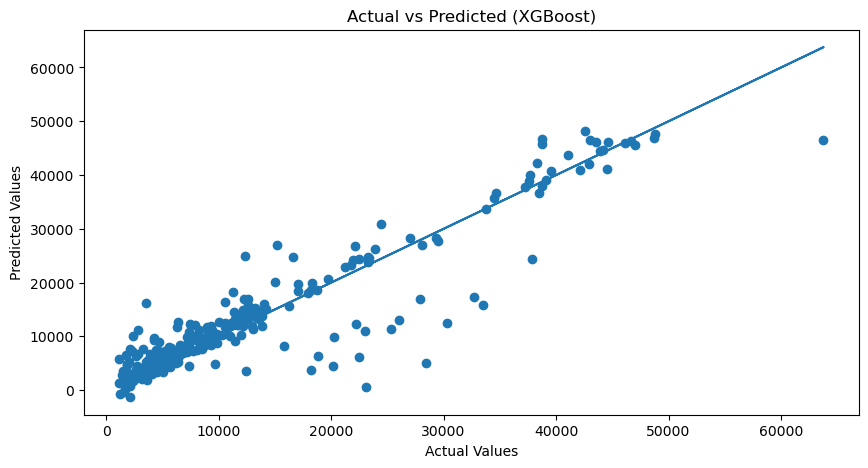

In [53]:
#graph
plt.figure(figsize= (10 , 5))
plt.scatter(y_test, y_pred_xgb)
plt.plot(y_test, y_test)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (XGBoost)")
plt.show()

In [41]:
# score of Linear
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
mae = mean_absolute_error(y_test , L_pred)
print("MAE : " , mae)

mse = mean_squared_error(y_test , L_pred)
print("MSE : " , mse)

rmse = np.sqrt(mse)
print("RMSE : " , rmse)

r2 = r2_score(y_test , L_pred)
print("R2-Score : " ,r2 )

MAE :  4311.331174027874
MSE :  33933847.470515765
RMSE :  5825.276600344036
R2-Score :  0.781422707004122


In [ ]:
#graph of LR
plt.figure(figsize = (10 , 5))
sns.histplot(y_test , kde = True , label = 'Actual')
sns.histplot(L_pred , kde = True , label = 'Predict')
plt.legend()
plt.show()

In [46]:
#Random forest Regression
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(x_train , y_train)

R_pred = model.predict(x_test)
print('Linear Predication : ' , R_pred[:5].round(2))

Linear Predication :  [13188.17  5120.84 28183.43 13476.96 34749.51]


In [47]:
# Scores of Forest
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
mae = mean_absolute_error(y_test , R_pred)
print("MAE : " , mae)

mse = mean_squared_error(y_test , R_pred)
print("MSE : " , mse)

rmse = np.sqrt(mse)
print("RMSE : " , rmse)

r2 = r2_score(y_test , R_pred)
print("R2-Score : " ,r2 )

MAE :  2516.798541209298
MSE :  20546699.552180443
RMSE :  4532.846738218759
R2-Score :  0.8676530277912822


In [ ]:
#graph of RFR
plt.figure(figsize = (10 , 5))
sns.histplot(y_test , kde = True , label = 'Actual')
sns.histplot(L_pred , kde = True , label = 'Predict')
plt.legend()
plt.show()

In [49]:
# campersion
print("Linear R2:", r2_score(y_test, L_pred))
print("Random Forest R2:", r2_score(y_test, R_pred))
print("XGBoost R2:", r2_score(y_test, y_pred_xgb))

Linear R2: 0.781422707004122
Random Forest R2: 0.8676530277912822
XGBoost R2: 0.8530144053469756


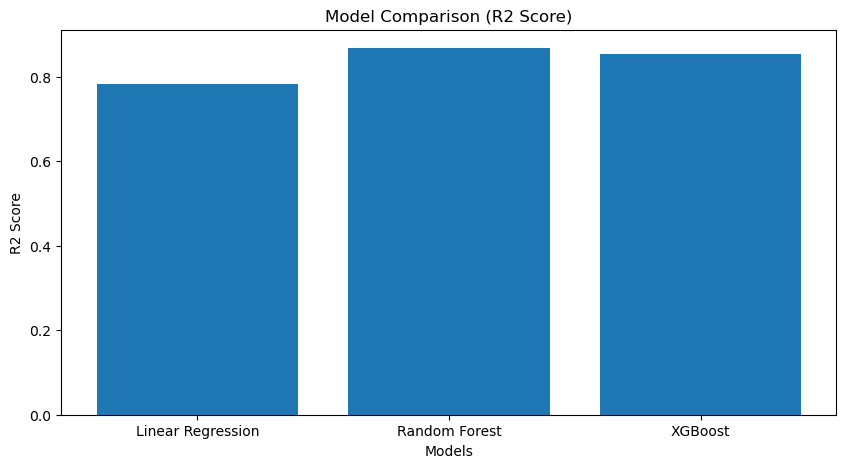

In [56]:
#graph of R2 score all three
models = ['Linear Regression', 'Random Forest', 'XGBoost']
r2_scores = [
    r2_score(y_test, L_pred),
    r2_score(y_test, R_pred),
    r2_score(y_test, y_pred_xgb)
]

plt.figure(figsize= (10 , 5))

plt.bar(models, r2_scores)
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()